Grayscale shape: (1280, 720)
RGB shape: (1280, 720, 3)
RGBA shape: (1280, 720, 4)


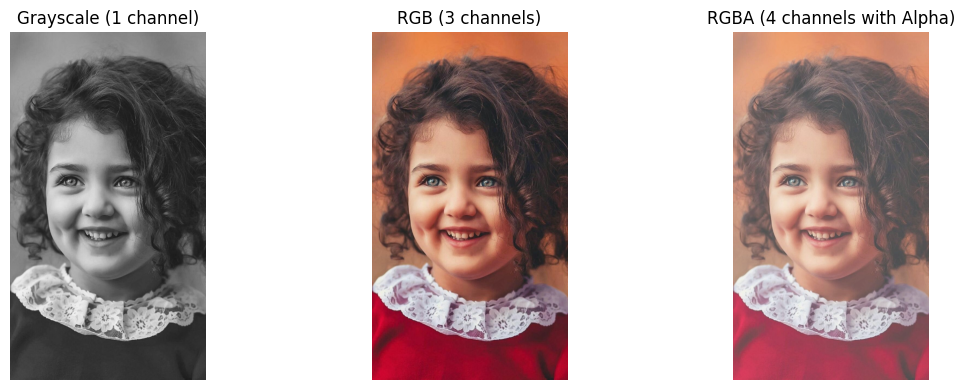

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Load image in different formats ---
gray = cv2.imread("pk.jpg", cv2.IMREAD_GRAYSCALE)   # 1 channel
rgb  = cv2.imread("pk.jpg", cv2.IMREAD_COLOR)       # 3 channels (BGR)

# --- Convert BGR → RGB for proper display ---
rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)

# --- Create an Alpha channel ---
# Alpha = 255 means fully opaque; smaller values mean transparent
alpha_channel = np.ones(rgb.shape[:2], dtype=np.uint8) * 200

# --- Combine RGB + Alpha to form RGBA ---
rgba = np.dstack((rgb, alpha_channel))

# --- Print shapes ---
print("Grayscale shape:", gray.shape)
print("RGB shape:", rgb.shape)
print("RGBA shape:", rgba.shape)

# --- Display images ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title('Grayscale (1 channel)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(rgb)
plt.title('RGB (3 channels)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(rgba)
plt.title('RGBA (4 channels with Alpha)')
plt.axis('off')

plt.tight_layout()
plt.show()


Grayscale shape: (1280, 720)
RGB shape: (1280, 720, 3)
RGBA shape: (1280, 720, 4)

Gray Pixel Matrix (first 5x5 block):
 [[138 137 136 136 136]
 [138 137 136 136 135]
 [137 137 136 135 135]
 [137 137 136 135 135]
 [137 136 135 135 135]]

RGB Pixel Matrix (first 5x5 block):
 [[[193 120  85]
  [192 119  84]
  [191 118  85]
  [191 118  85]
  [191 118  85]]

 [[193 120  85]
  [192 119  84]
  [191 118  85]
  [191 118  85]
  [190 117  84]]

 [[192 119  86]
  [192 119  86]
  [191 118  85]
  [190 117  84]
  [190 117  84]]

 [[192 119  86]
  [192 119  86]
  [191 118  85]
  [190 117  84]
  [190 117  84]]

 [[192 119  86]
  [191 118  85]
  [190 117  84]
  [190 117  84]
  [190 117  84]]]

RGBA Pixel Matrix (first 5x5 block):
 [[[193 120  85 255]
  [192 119  84 255]
  [191 118  85 255]
  [191 118  85 255]
  [191 118  85 255]]

 [[193 120  85 255]
  [192 119  84 255]
  [191 118  85 255]
  [191 118  85 255]
  [190 117  84 255]]

 [[192 119  86 255]
  [192 119  86 255]
  [191 118  85 255]
  [190 117  

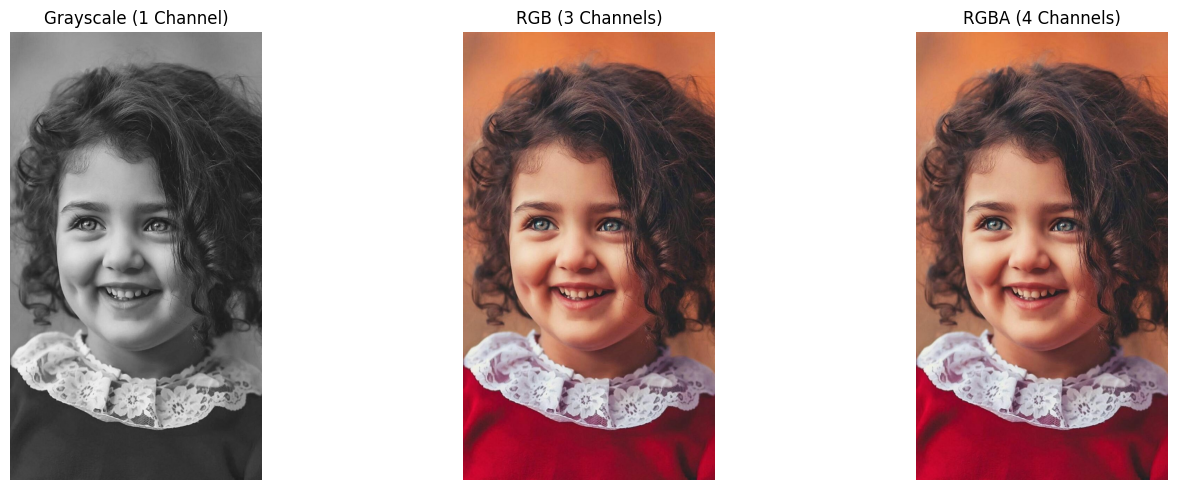

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Load the image ---
gray = cv2.imread("pk.jpg", cv2.IMREAD_GRAYSCALE)   # Grayscale (1 channel)
rgb = cv2.imread("pk.jpg", cv2.IMREAD_COLOR)        # RGB (actually BGR)
rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)          # Convert to RGB

# --- Add Alpha Channel ---
alpha_channel = np.ones(rgb.shape[:2], dtype=np.uint8) * 255  # Fully opaque alpha
rgba = np.dstack((rgb, alpha_channel))                        # Combine to RGBA

# --- Print Image Shapes ---
print("Grayscale shape:", gray.shape)
print("RGB shape:", rgb.shape)
print("RGBA shape:", rgba.shape)

# --- Print Pixel Matrices (smaller section for readability) ---
print("\nGray Pixel Matrix (first 5x5 block):\n", gray[:5, :5])
print("\nRGB Pixel Matrix (first 5x5 block):\n", rgb[:5, :5, :])
print("\nRGBA Pixel Matrix (first 5x5 block):\n", rgba[:5, :5, :])

# --- Display Images ---
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title('Grayscale (1 Channel)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(rgb)
plt.title('RGB (3 Channels)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(rgba)
plt.title('RGBA (4 Channels)')
plt.axis('off')

plt.tight_layout()
plt.show()


Image has no alpha channel — adding one manually (fully opaque).


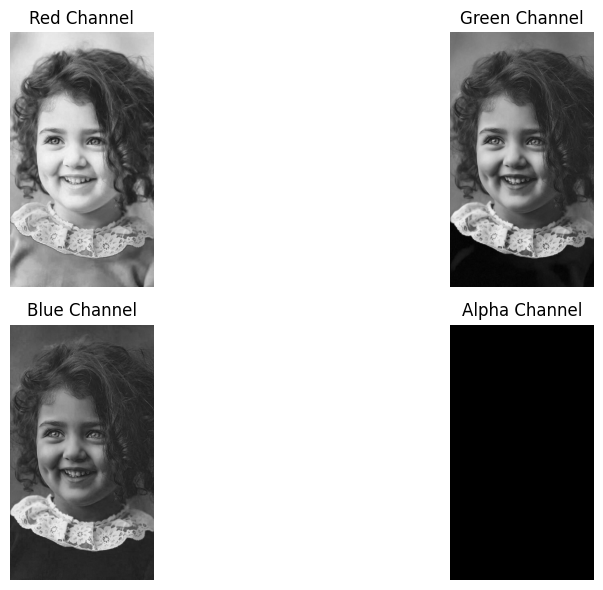

🔴 Red Channel Matrix (top-left 5x5):
 [[193 192 191 191 191]
 [193 192 191 191 190]
 [192 192 191 190 190]
 [192 192 191 190 190]
 [192 191 190 190 190]]

🟢 Green Channel Matrix (top-left 5x5):
 [[120 119 118 118 118]
 [120 119 118 118 117]
 [119 119 118 117 117]
 [119 119 118 117 117]
 [119 118 117 117 117]]

🔵 Blue Channel Matrix (top-left 5x5):
 [[85 84 85 85 85]
 [85 84 85 85 84]
 [86 86 85 84 84]
 [86 86 85 84 84]
 [86 85 84 84 84]]

⚪ Alpha Channel Matrix (top-left 5x5):
 [[255 255 255 255 255]
 [255 255 255 255 255]
 [255 255 255 255 255]
 [255 255 255 255 255]
 [255 255 255 255 255]]


In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Load image with alpha support ---
image = cv2.imread("pk.jpg", cv2.IMREAD_UNCHANGED)  # This loads alpha if it exists

# Check number of channels
if image.shape[2] == 3:
    print("Image has no alpha channel — adding one manually (fully opaque).")
    # Add an alpha channel (255 = fully opaque)
    alpha = np.ones(image.shape[:2], dtype=np.uint8) * 255
    image_rgba = cv2.merge((image, alpha))
else:
    print("Image already has an alpha channel.")
    image_rgba = image

# Convert BGR → RGBA for correct color order
image_rgba = cv2.cvtColor(image_rgba, cv2.COLOR_BGRA2RGBA)

# --- Separate channels ---
R = image_rgba[:, :, 0]
G = image_rgba[:, :, 1]
B = image_rgba[:, :, 2]
A = image_rgba[:, :, 3]

# --- Display all channels ---
plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plt.imshow(R, cmap='gray')
plt.title('Red Channel')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(G, cmap='gray')
plt.title('Green Channel')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(B, cmap='gray')
plt.title('Blue Channel')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(A, cmap='gray')
plt.title('Alpha Channel')
plt.axis('off')

plt.tight_layout()
plt.show()

# --- Print example pixel matrices ---
print("🔴 Red Channel Matrix (top-left 5x5):\n", R[:5, :5])
print("\n🟢 Green Channel Matrix (top-left 5x5):\n", G[:5, :5])
print("\n🔵 Blue Channel Matrix (top-left 5x5):\n", B[:5, :5])
print("\n⚪ Alpha Channel Matrix (top-left 5x5):\n", A[:5, :5])
